In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## TASK 1

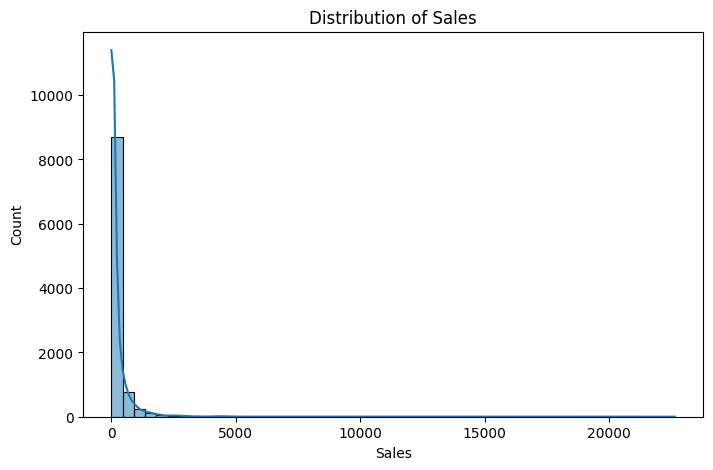

Skewness: 12.97
Mean: 229.86
Median: 54.49


In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

# Plotting Histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True, bins=50)
plt.title('Distribution of Sales')
plt.show()

# Calculating metrics
sales_skew = df['Sales'].skew()
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()

print(f"Skewness: {sales_skew:.2f}")
print(f"Mean: {sales_mean:.2f}")
print(f"Median: {sales_median:.2f}")

# EXPLANATION:

  

*   The sales distribution is highly rightly skewed with a value of 12.97 skewness
*   The mean (229.86) is significantly larger than the median (54.49). Because of this heavy skew and extreme outliers pulling the average upward, the mean is not a reliable summary of a "typical" sale.



## TASK 2

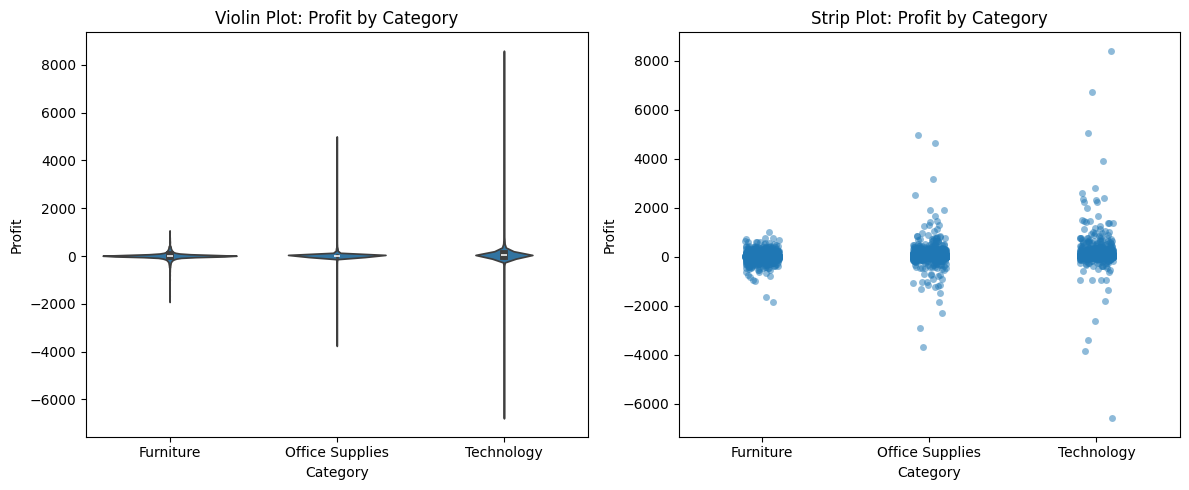

In [3]:
plt.figure(figsize=(12, 5))

# Violin Plot
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x='Category', y='Profit')
plt.title('Violin Plot: Profit by Category')

# Strip Plot
plt.subplot(1, 2, 2)
sns.stripplot(data=df, x='Category', y='Profit', jitter=True, alpha=0.5)
plt.title('Strip Plot: Profit by Category')

plt.tight_layout()
plt.show()

# EXPLANATION:
  
  The violin plot better reveals categories with bimodal or unusually spread-out distributions because it estimates and shows the full density surface. In datasets with thousands of points, a strip plot becomes a crowded blob, making it harder to discern where the bulk of the data actually lies.

## TASK 3

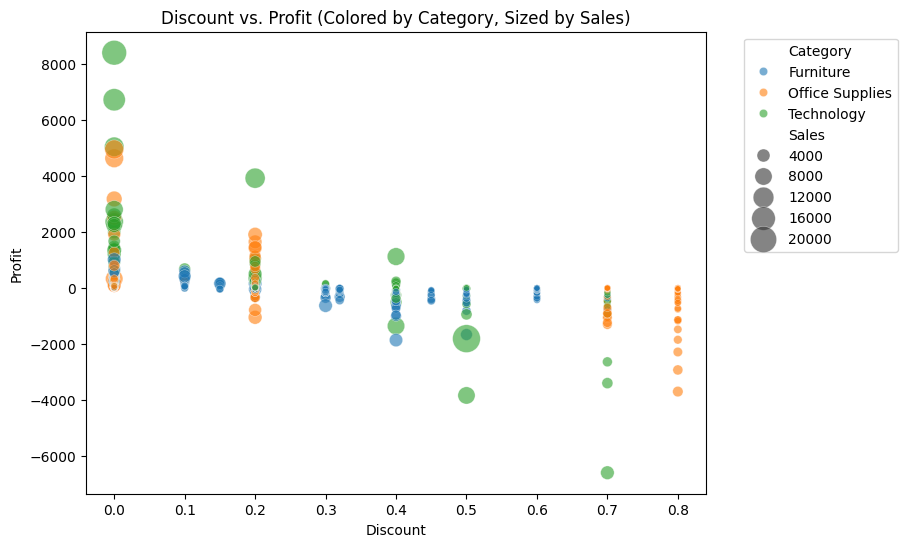

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales', sizes=(20, 400), alpha=0.6)
plt.title('Discount vs. Profit (Colored by Category, Sized by Sales)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# EXPLANATION:

By sizing the points by Sales, a clear pattern emerges: the largest losses (huge negative profit points) almost exclusively occur when deep discounts (above 0.4) are applied to massive sales orders, particularly in the Technology and Office Supplies categories.

## TASK 4

In [5]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

print("Pearson Correlation:\n", pearson_corr)
print("\nSpearman Correlation:\n", spearman_corr)

Pearson Correlation:
              Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000

Spearman Correlation:
              Sales  Quantity  Discount    Profit
Sales     1.000000  0.327426 -0.056969  0.518407
Quantity  0.327426  1.000000 -0.000878  0.234491
Discount -0.056969 -0.000878  1.000000 -0.543350
Profit    0.518407  0.234491 -0.543350  1.000000


# EXPLANATION:



*   The most noticeable disagreement occurs between Discount and Profit. Pearson reports a weak linear correlation (-0.219), while Spearman reports a much stronger monotonic relationship (-0.543).
*   This disagreement happens because Pearson is highly sensitive to extreme outliers (massive individual profits or losses) and strictly evaluates linearity. Spearman uses rank-ordering, exposing that as discounts increase, profit ranks reliably decrease, even if the trajectory isn't perfectly a straight line
*   Caveat: Correlation is not causation; higher discounts and lower profits might move together because of overlapping inventory clearance policies rather than one strictly causing the exact drop in the other.





## TASK 5

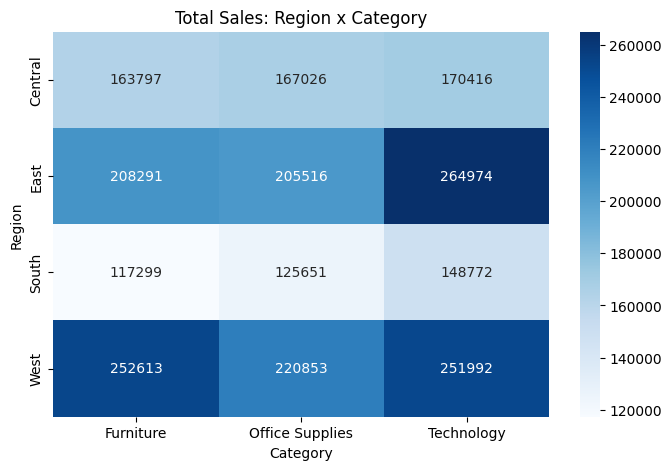

In [6]:
pivot_df = pd.pivot_table(df, index='Region', columns='Category', values='Sales', aggfunc='sum', margins=True)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_df.iloc[:-1, :-1], annot=True, fmt=".0f", cmap='Blues')
plt.title('Total Sales: Region x Category')
plt.show()

# EXPLANATION:

The combination of the East Region and the Technology Category contributes the most to overall revenue (264,974 in total sales).

## TASK 6

/tmp/ipykernel_1152/2590252999.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_time['Sales'].resample('M').sum()


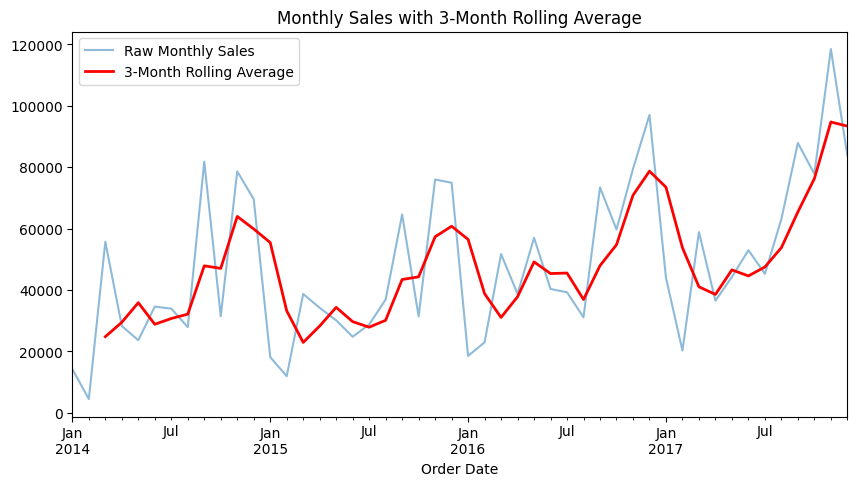

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_time = df.set_index('Order Date')

monthly_sales = df_time['Sales'].resample('M').sum()
rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(label='Raw Monthly Sales', alpha=0.5)
rolling_avg.plot(label='3-Month Rolling Average', color='red', linewidth=2)
plt.title('Monthly Sales with 3-Month Rolling Average')
plt.legend()
plt.show()

# EXPLANATION:
The 3-month rolling average smooths out the chaotic, month-to-month volatility of the raw data. It clearly reveals the underlying seasonal growth trend, showing that sales consistently build up slowly during the first half of the year and peak significantly in the final quarter.

## TASK 7

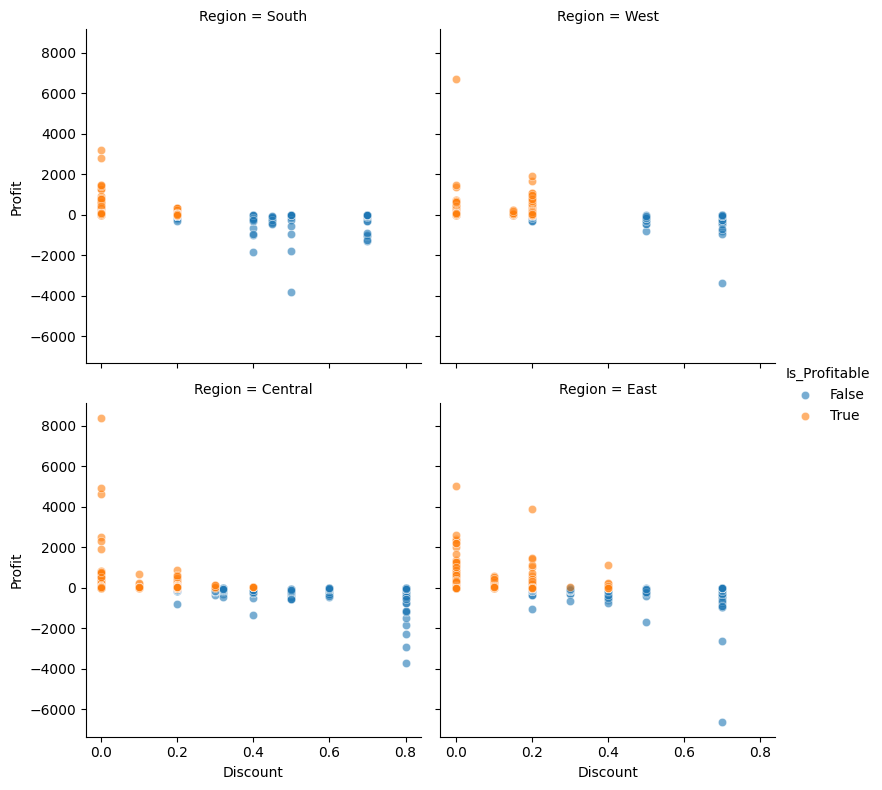

In [8]:
df['Is_Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col='Region', hue='Is_Profitable', col_wrap=2, height=4)
g.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.6)
g.add_legend()
plt.show()

# EXPLANATION:

The Central region visibly differs from the others. It is the only region that issues extreme discounts at the 0.8 level, which uniformly lead to a dense cluster of entirely unprofitable orders.

## TASK 8

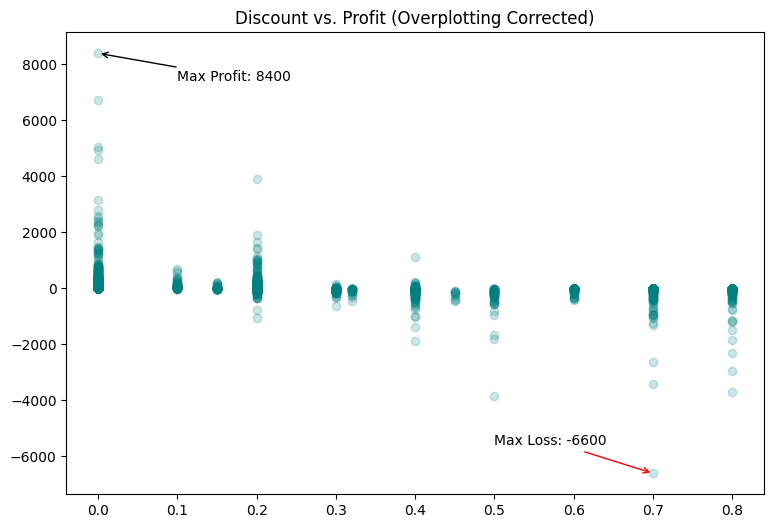

In [9]:
plt.figure(figsize=(9, 6))

# Using alpha for ~10k points
plt.scatter(df['Discount'], df['Profit'], alpha=0.2, color='teal')

# Identifying extremes
best = df.loc[df['Profit'].idxmax()]
worst = df.loc[df['Profit'].idxmin()]

# Annotating best
plt.annotate(f"Max Profit: {best['Profit']:.0f}", xy=(best['Discount'], best['Profit']),
             xytext=(best['Discount'] + 0.1, best['Profit'] - 1000),
             arrowprops=dict(arrowstyle='->', color='black'))

# Annotating worst
plt.annotate(f"Max Loss: {worst['Profit']:.0f}", xy=(worst['Discount'], worst['Profit']),
             xytext=(worst['Discount'] - 0.2, worst['Profit'] + 1000),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Discount vs. Profit (Overplotting Corrected)')
plt.show()

# EXPLANATION
Because the dataset contains around 10,000 points (moderate overlap), applying alpha=0.2 transparency is the most appropriate fix. Hexbinning is generally reserved for much larger datasets exceeding 50,000 points.